
=== REPORTE RANDOM FOREST ===
              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1554
        True       0.62      0.49      0.55       556

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.78      0.79      0.78      2110



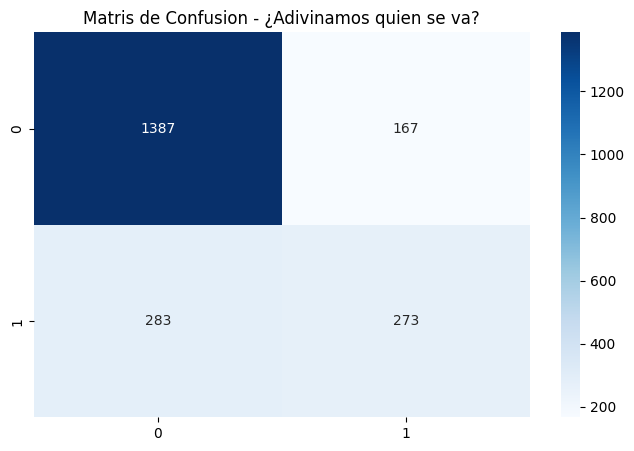

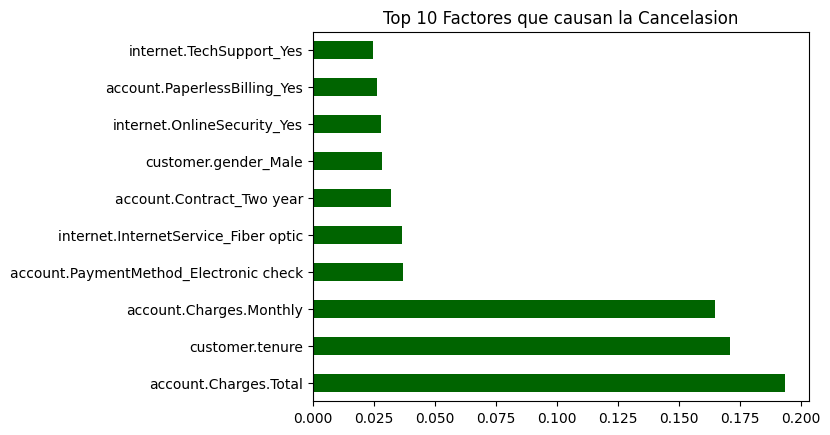

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# --- 1. CARGA Y LIMPESA (Usando el JSON oficial) ---
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'
df = pd.json_normalize(pd.read_json(url).to_dict(orient='records'))

# Tratamiento de datos que ya saves
df['account.Charges.Total'] = pd.to_numeric(df['account.Charges.Total'], errors='coerce')
df.dropna(inplace=True)
df = df[df['Churn'] != '']

# --- 2. PREPARASION PARA EL MODELO ---
# Eliminamos el ID pq no aporta valor predictivo
df_ml = df.drop(columns=['customerID'])

# Codificasion: pasamos categorias a numeros (One-Hot Encoding)
df_ml = pd.get_dummies(df_ml, drop_first=True)

# Separamos la variable objetivo (y) de las caracteristicas (X)
X = df_ml.drop('Churn_Yes', axis=1)
y = df_ml['Churn_Yes']

# Division: 70% entrenamiento y 30% para testeo
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- 3. MODELO 1: Regresion Logistica (Requiere normalisacion) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression()
log_model.fit(X_train_scaled, y_train)
y_pred_log = log_model.predict(X_test_scaled)

# --- 4. MODELO 2: Random Forest (No requiere normalisacion) ---
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# --- 5. EVALUASION Y METRICAS ---
print("\n=== REPORTE RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))

# Matris de confusion para el mejor modelo
plt.figure(figsize=(8,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Matris de Confusion - ¿Adivinamos quien se va?')
plt.show()



# Importansia de las variables (¿Que influye mas?)
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
importances.plot(kind='barh', color='darkgreen')
plt.title('Top 10 Factores que causan la Cancelasion')
plt.show()